# Practice notebook for multivariate analysis using NHANES data
This notebook will give you the opportunity to perform some multivariate analyses on your own using the NHANES case study data. These analyses are similar to what was done inthe week 2 NHANES case study notebook.<br><br>
You can enter your code into the cells that say "enter your code here", and you can type responses to the questions into the cells that say "Type Markdown and Latex".<br><br>Note that most of the code that you will need to write below is very similar to code that appears in the case study notebook. You will need to edit code from that notebook in small ways to adapt it to the prompts below.<br><br>
To get startde, we will use the same module imports and read the data in the same way as we did in the case study:

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import numpy as np

df = pd.read_csv('../../../data/raw/statistics_python/nhanes_2015_2016.csv')
df.columns

Index(['SEQN', 'ALQ101', 'ALQ110', 'ALQ130', 'SMQ020', 'RIAGENDR', 'RIDAGEYR',
       'RIDRETH1', 'DMDCITZN', 'DMDEDUC2', 'DMDMARTL', 'DMDHHSIZ', 'WTINT2YR',
       'SDMVPSU', 'SDMVSTRA', 'INDFMPIR', 'BPXSY1', 'BPXDI1', 'BPXSY2',
       'BPXDI2', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXLEG', 'BMXARML', 'BMXARMC',
       'BMXWAIST', 'HIQ210'],
      dtype='str')

## Question 1
Make a scatterplot showing the relationship between the first and second measurements of diastolic blood pressure (BPXDI1 and BPXDI2). Also obtain the 4x4 matrix of correlation coefficients among the first two systolic and the first two diastolic blod pressure measures.

          BPXDI1    BPXDI2
BPXDI1  1.000000  0.884722
BPXDI2  0.884722  1.000000
          BPXSY1    BPXSY2
BPXSY1  1.000000  0.962287
BPXSY2  0.962287  1.000000


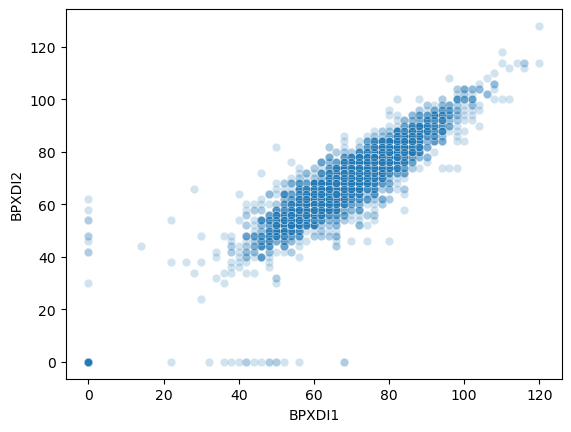

In [17]:
sns.scatterplot(data=df, x='BPXDI1', y='BPXDI2', alpha=0.2)
print(df[['BPXDI1', 'BPXDI2']].corr())
print(df[['BPXSY1','BPXSY2']].corr())

**Q1a**. How does the correlation between repeated measurements of diastolic blood pressure compare to the correlation between repeated measurements of systolic blood pressure?<br><br>

A correlação entre as medidas de pressão sanguínea sistólica tem maior correlação que as medições de pressão diastólica sanguínea.

**Q2a**. Are the second systolic and second disatolic blood pressure measure more correlated or less correlated than the first systolic and first diastolic blood pressuyre measure?

In [4]:
print(df[['BPXSY1','BPXDI1']].corr())
print(df[['BPXSY2','BPXDI2']].corr())

          BPXSY1    BPXDI1
BPXSY1  1.000000  0.316531
BPXDI1  0.316531  1.000000
          BPXSY2    BPXDI2
BPXSY2  1.000000  0.303847
BPXDI2  0.303847  1.000000


A correlação é praticamente a mesma. 

## Question 2
Calculate the correlation coefficient between the first measures of diastolic and systolic blood pressure within each subgroup defined by sex and ethnicity. Then construct a grid of scatterplots between the first systolic and the first diastolic blood pressure measurement stratified by sex (rows) and race/ethnicity groups (columns).

In [21]:
df['RIAGENDR'] = df['RIAGENDR'].replace({1:'Male', 2: 'Female'})
print(df.groupby(['RIAGENDR', 'RIDRETH1'])[['BPXDI1','BPXSY1']].corr())


                            BPXDI1    BPXSY1
RIAGENDR RIDRETH1                           
Female   1        BPXDI1  1.000000  0.351912
                  BPXSY1  0.351912  1.000000
         2        BPXDI1  1.000000  0.239737
                  BPXSY1  0.239737  1.000000
         3        BPXDI1  1.000000  0.241947
                  BPXSY1  0.241947  1.000000
         4        BPXDI1  1.000000  0.378335
                  BPXSY1  0.378335  1.000000
         5        BPXDI1  1.000000  0.438976
                  BPXSY1  0.438976  1.000000
Male     1        BPXDI1  1.000000  0.302742
                  BPXSY1  0.302742  1.000000
         2        BPXDI1  1.000000  0.306427
                  BPXSY1  0.306427  1.000000
         3        BPXDI1  1.000000  0.207470
                  BPXSY1  0.207470  1.000000
         4        BPXDI1  1.000000  0.423597
                  BPXSY1  0.423597  1.000000
         5        BPXDI1  1.000000  0.370852
                  BPXSY1  0.370852  1.000000


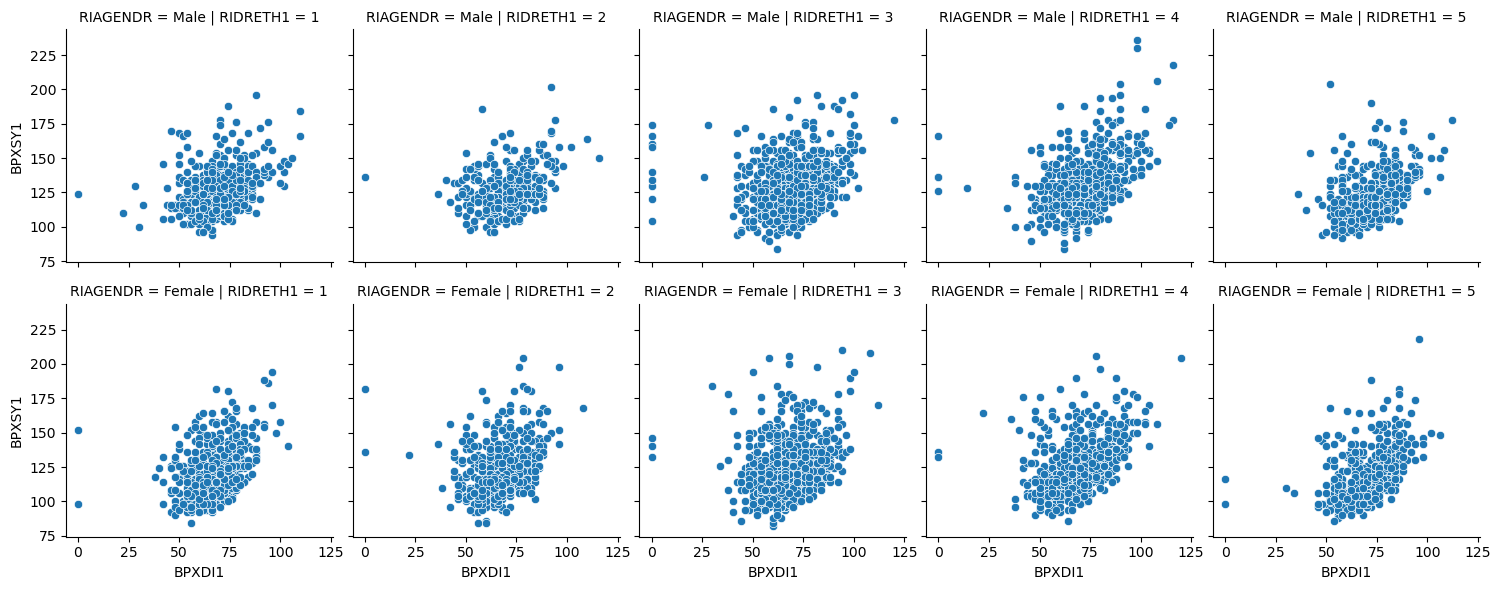

In [24]:
sns.FacetGrid(df, col="RIDRETH1", row="RIAGENDR").map(sns.scatterplot, "BPXDI1", "BPXSY1")

**Q2a.** Comment on the extent on wichi these two blood pressure variables are correlated to different degrees in different demographipc subgroups.<br><br>

## Question 3
Use "violin plots" to compare the distributions of ages within groups defined by sex and education attainment.

Axes(0.125,0.11;0.775x0.77)


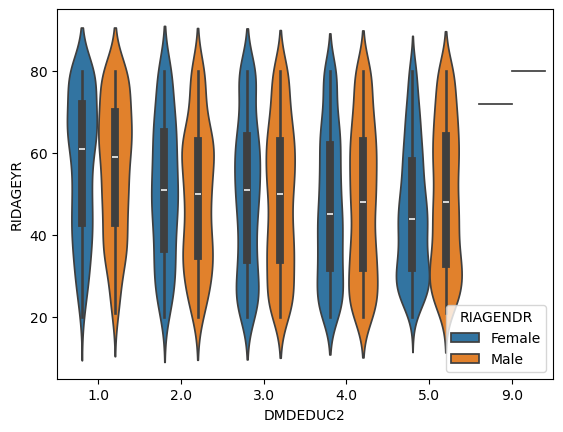

In [32]:
print(sns.violinplot(data=df, y='RIDAGEYR', x='DMDEDUC2', hue='RIAGENDR'))

**Q3a.** Comment on any evident differences among the age distributions in the different demographic groups.<br><br>

# Question 4
Use violin plots to compare the distributions of BMI within a series of 10 years-age bands. Also stratify these plots by gender.

**Q4a**. Comment on the differences in BMI across the demographic groups.

# Question 5
Construct a frequency table for the joint distribution of ethnicity groups (RIDRETH1) and health-insurance status (HIQ210). Normalize the results so that the values within each ethnic group are proportions that sum to 1.

**Q5a**. Which ethnic group has the highest rate of being uninsured in the past year?